In [1]:
# this is essentially going to be the code jill wrote in time_cutoffs.ipynb (jill branch)
# but i rewrite here to both learn how it works and to make sure the object types between this and PSDProd will play nice

In [15]:
# standard imports
import pandas as pd
import numpy as np
import csv
from scipy.signal import welch
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300

In [83]:
# set up windowing params globally
sampFreq = 100
window_half_width = 5 # enforce that this is seconds somehow
halfWIndex = window_half_width * sampFreq

In [ ]:
# # import CSVs and such
# voltagedata = pd.read_csv('../testsAndSuch/output/stationTest.CSV') # it seems like this is the old 10 Hz sampling :(
# voltagedata['voltage'] = voltagedata['sensor'] * (5 / 16383)
sampFreq = 100

# # import clicker data, unfortunately this does not exists on the repo :(
# # events every 200 seconds, should give enough room for both event and background
# clickerdata = pd.read_csv('../testsAndSuch/output/clickerFAKE.csv')

# now want to control the windowing params around events
window_half_width = 5 # enforce that this is seconds somehow
# voltagedata['seconds'] = pd.to_numeric(voltagedata['seconds'], errors='coerce')
# clickerdata['seconds'] = pd.to_numeric(clickerdata['seconds'], errors='coerce')

# voltDrop = voltagedata.dropna(subset=['seconds']).reset_index(drop=True)
# clickDrop = clickerdata.dropna(subset=['seconds']).reset_index(drop=True)

In [85]:
def arrayExtract(fpath,voltCon,endCut=10,fs=100):
    # import csv and prep colums
    DF = pd.read_csv(fpath)
    DF['seconds'] = pd.to_numeric(DF['seconds'],errors='coerce')
    DF['sensor'] = pd.to_numeric(DF['sensor'],errors='coerce')
    DF = DF.dropna(subset=['seconds']).reset_index(drop=True)

    # now want to make chops
    endIdx = endCut*fs # endCut in seconds, fs in Hz
    DFSecs = DF['seconds']
    DFSecs = DFSecs[endIdx:-endIdx]
    DFSens = DF['sensor']
    DFSens = DFSens[endIdx:-endIdx]
    DFVolt = DFSens * voltCon
    return DFSecs,DFSens,DFVolt

In [86]:
# copilot generated function to convert csv from clicker into seconds elapsed

def utcSecondsConv(csv_path, sort_ascending=True):
    """
    Parse lines like: HH:MM:SS.s,UTC
    Return NumPy array of seconds elapsed since 00:00:00 UTC.
    """
    seconds = []

    with open(csv_path, newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        for row in reader:
            # Keep only rows that look like: time,UTC
            if len(row) < 2 or row[1].strip().upper() != "UTC":
                continue

            t = row[0].strip()
            parts = t.split(":")
            if len(parts) != 3:
                continue

            hh = int(parts[0])
            mm = int(parts[1])
            ss = float(parts[2])   # supports fractional seconds

            seconds.append(hh * 3600 + mm * 60 + ss)

    arr = np.array(seconds, dtype=float)
    if sort_ascending:
        arr = np.sort(arr)
    return arr

In [87]:
clickArr = utcSecondsConv('../clickerFiles/04_12_26545-620.csv')

In [88]:
unoSecs,unoSens,unoVolt = arrayExtract('../SDCardOut/uno/concurrentUNO1.CSV',5/16383)

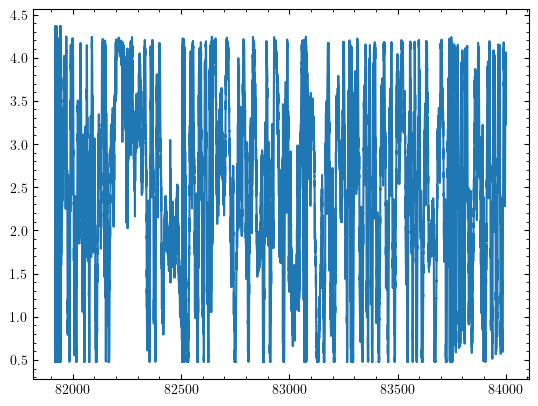

In [89]:
plt.plot(unoSecs,unoVolt)

In [90]:
clickArr

array([82093.2, 82150.9, 82451.5, 82502.2, 82625.5, 83016.4, 83065.5,
       83239.5, 83278.6, 83689.2, 83736.1, 84055. ])

In [91]:
# bigVoltArr = voltagedata['voltage'].to_numpy()

In [92]:
# # initial seconds may not line up, want to shift
# # im not quite sure why we want both to start at 0 tho? then it feels like we would mismatch
# # if the first event is when the seismometer starts recording, then we should drop the first entry in clickAdjSecs
# # if the clicks are UTC seconds, adjust as below
# # if not, figure it out bruh
# t0Volt = voltDrop['seconds'].iloc[0]
# t0Click = clickDrop['seconds'].iloc[0]

# voltDrop['adjSecs'] = voltDrop['seconds'] - t0Volt
# clickDrop['adjSecs'] = clickDrop['seconds'] - t0Click

# voltSecs = voltDrop['seconds'].to_numpy()
# clickSecs = clickDrop['seconds'].to_numpy()
# voltAdjSecs = voltDrop['adjSecs'].to_numpy()
# clickAdjSecs = clickDrop['adjSecs'].to_numpy()

# print(f'voltage csv first time was {t0Volt}, now is {voltAdjSecs[0]}')
# print(f'clicker csv first time was {t0Click}, now is {clickAdjSecs[0]}')

# # kill entry in clickAdjSecs for recording start
# clickAdjSecs = clickAdjSecs[1:]

In [93]:
# want to pull indexes from the UTC event times
def eventIdx(secs,clicker):
    idxArr = []
    for event in clicker:
        eventIdx = np.searchsorted(secs,event)
        idxArr.append(eventIdx)
    return np.array(idxArr)

In [94]:
indxArr = eventIdx(unoSecs,clickArr)
indxArr

array([ 1746,  2324,  5328,  5835,  7067, 10975, 11465, 13204, 13595,
       17699, 18168, 20817])

In [95]:
# # jill wrote a complicated matching thing, which looks nice but i imagine for our purposes some type of searchsorted would work fineish
# eventIdxArr = []
# for event in clickAdjSecs:
#     eventIdx = np.searchsorted(voltAdjSecs,event)
#     eventIdxArr.append(eventIdx)
# eventIdxArr = np.array(eventIdxArr)

# eventIdxArr

In [96]:
# comment for reference in 5 minutes...
# add half window width to each event index
# then, make array of tuples for these guys
# inside the window indexes are events, then make another array with indexes between the windows as bckgd
# then we can slice and dice how we please

In [ ]:
def windowMaker(arr,idxarr,halfWIndex=halfWIndex,):
    # kind of a big function but it should output lists of arrays with event and background segregated
    # first need to make some cutoff indices
    noiseWIndex = []
    eventWIndex = []
    n = len(arr)

    # now we construct prelim event windows
    for idx in idxarr:
        low = max(0,int(idx-halfWIndex))
        high = min(n-1,int(idx+halfWIndex))
        eventWIndex.append([low,high])
    
    # then here we merge if any overlap
    eventWIndex.sort(key=lambda w: w[0])
    merged = []
    for low, high in eventWIndex:
        if not merged or low > merged[-1][1] + 1:
            merged.append([low,high])
        else:
            merged[-1][1] = max(merged[-1][1],high)
    
    eventWIndex = merged

    # now the remaining values are all background noise
    cursor = 0
    for low,high in eventWIndex:
        if cursor < low:
            noiseWIndex.append([cursor,low-1])
        cursor = high + 1 
    
    if cursor <= n-1:
        noiseWIndex.append([cursor,n-1])
    
    # enforce these windows upon the voltage and seconds arrs
    noiseArrs = []
    for low,high in noiseWIndex:
        noiseArrs.append(arr[low:high])
    eventArrs = []
    for low,high in eventWIndex:
        eventArrs.append(arr[low:high])

    return eventArrs,noiseArrs

In [98]:
# # thank you evil death robot for writing this for me
# noiseWIndex = []
# eventWIndex = []

# n = len(voltAdjSecs)  # total valid sample indices: 0 .. n-1

# # 1) Build raw event windows [low, high] around each event index
# for idx in eventIdxArr:
#     low = max(0, int(idx - halfWIndex))
#     high = min(n - 1, int(idx + halfWIndex))
#     eventWIndex.append([low, high])

# # 2) Sort + merge overlapping/touching event windows
# eventWIndex.sort(key=lambda w: w[0])
# merged = []
# for low, high in eventWIndex:
#     if not merged or low > merged[-1][1] + 1:
#         merged.append([low, high])
#     else:
#         merged[-1][1] = max(merged[-1][1], high)

# eventWIndex = merged

# # 3) Fill gaps as noise windows (complement of event windows)
# cursor = 0
# for low, high in eventWIndex:
#     if cursor < low:
#         noiseWIndex.append([cursor, low - 1])
#     cursor = high + 1

# if cursor <= n - 1:
#     noiseWIndex.append([cursor, n - 1])

# print("eventWIndex:", eventWIndex)
# print("noiseWIndex:", noiseWIndex)

In [99]:
# noiseArrs = []
# for low,high in noiseWIndex:
#     noiseArrs.append(bigVoltArr[low:high])

# eventArrs = []
# for low,high in eventWIndex:
#     eventArrs.append(bigVoltArr[low:high])

In [100]:
unoEventArrs,unoNoiseArrs = windowMaker(unoVolt,indxArr)